# Notebook 02 — Data Preprocessing

**PharmaLens: An Explainable AI Framework for Drug–Target Interaction Prediction**

---

## Objective

This notebook cleans and validates the raw KIBA dataset to produce a reliable, ready-to-use dataset for feature extraction and model training.

We will:
1. Validate drug SMILES strings using RDKit (remove invalid molecules)
2. Canonicalize SMILES (standardize chemical representations)
3. Validate protein sequences (check amino acid alphabet)
4. Handle duplicate and missing records
5. Analyze interaction scores and detect outliers
6. Create train/validation/test splits
7. Save the cleaned dataset

**Why this matters:** Invalid SMILES or protein sequences would cause errors during feature extraction. Inconsistent data would produce unreliable model results. This cleaning step is essential for scientific integrity.

## Setup

In [1]:
import os
import sys
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Add project root to path
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.utils.config import (
    PROCESSED_DATA_DIR, METADATA_DIR, FIGURES_DIR, SPLITS_DIR,
    ensure_dirs, set_seed, set_plot_style, save_json
)
from src.preprocessing.drug_preprocessor import preprocess_drugs, validate_smiles, canonicalize_smiles
from src.preprocessing.protein_preprocessor import preprocess_proteins, validate_sequence
from src.preprocessing.interaction_preprocessor import preprocess_interactions
from src.evaluation.split_strategies import (
    random_split, cold_drug_split, cold_target_split,
    save_splits, summarize_split
)

set_seed(42)
COLORS = set_plot_style()
ensure_dirs()

print("Setup complete ✓")

Setup complete ✓


## 1. Load Raw Data

In [2]:
# Load the raw interaction DataFrame from Notebook 01
raw_path = PROCESSED_DATA_DIR / "kiba_raw_interactions.csv"
df = pd.read_csv(raw_path)

print(f"Loaded raw interactions: {len(df):,} rows")
print(f"Columns: {list(df.columns)}")
print(f"Unique drugs: {df['drug_id'].nunique()}")
print(f"Unique targets: {df['target_id'].nunique()}")
df.head()

Loaded raw interactions: 118,254 rows
Columns: ['drug_id', 'target_id', 'smiles', 'sequence', 'score']
Unique drugs: 2111
Unique targets: 229


,drug_id,target_id,smiles,sequence,score
0,CHEMBL1087421,O00141,COC1=C(C=C2C(=C1)CCN=C2C3=CC(=C(C=C3)Cl)Cl)Cl,MTVKTEAAKGTLTYSRMRGMVAILIAFMKQRRMGLNDFIQKIANNS...,11.1
1,CHEMBL1087421,O14920,COC1=C(C=C2C(=C1)CCN=C2C3=CC(=C(C=C3)Cl)Cl)Cl,MSWSPSLTTQTCGAWEMKERLGTGGFGNVIRWHNQETGEQIAIKQC...,11.1
2,CHEMBL1087421,O15111,COC1=C(C=C2C(=C1)CCN=C2C3=CC(=C(C=C3)Cl)Cl)Cl,MERPPGLRPGAGGPWEMRERLGTGGFGNVCLYQHRELDLKIAIKSC...,11.1
3,CHEMBL1087421,P00533,COC1=C(C=C2C(=C1)CCN=C2C3=CC(=C(C=C3)Cl)Cl)Cl,MRPSGTAGAALLALLAALCPASRALEEKKVCQGTSNKLTQLGTFED...,11.1
4,CHEMBL1087421,P04626,COC1=C(C=C2C(=C1)CCN=C2C3=CC(=C(C=C3)Cl)Cl)Cl,MELAALCRWGLLLALLPPGAASTQVCTGTDMKLRLPASPETHLDML...,11.1


## 2. Drug (SMILES) Preprocessing

**SMILES** (Simplified Molecular-Input Line-Entry System) is a text-based representation of chemical structures.

We validate each SMILES string using **RDKit** — an open-source cheminformatics library:
1. Check if the SMILES represents a valid molecule
2. Remove any salts or disconnected fragments (keep the largest fragment)
3. Convert to canonical form (a standardized unique representation)

In [3]:
# Validate all unique SMILES before preprocessing
unique_smiles = df['smiles'].unique()
print(f"Total unique SMILES strings: {len(unique_smiles)}")

# Quick validation check
valid_count = sum(1 for s in unique_smiles if validate_smiles(s))
invalid_count = len(unique_smiles) - valid_count
print(f"Valid SMILES: {valid_count}")
print(f"Invalid SMILES: {invalid_count}")

if invalid_count > 0:
    print("\nExamples of invalid SMILES:")
    for s in unique_smiles:
        if not validate_smiles(s):
            print(f"  {s[:80]}")
            invalid_count -= 1
            if invalid_count <= 3:
                break

Total unique SMILES strings: 2068
Valid SMILES: 2068
Invalid SMILES: 0


In [9]:
# Run the full drug preprocessing pipeline
df_drug_clean, drug_report = preprocess_drugs(df.copy(), smiles_col='smiles')

print(f"\n{'='*50}")
print(f"  DRUG PREPROCESSING REPORT")
print(f"{'='*50}")
print(f"  Before: {drug_report['original_count']:>10,} rows")
print(f"  After:  {drug_report['final_count']:>10,} rows")
print(f"  Removed:{drug_report['total_removed']:>10,} rows")
print(f"  Unique drugs after: {drug_report.get('unique_drugs_after', 'N/A')}")
print(f"{'='*50}")
print("\nSteps:")
for step in drug_report['steps']:
    print(f"  {step['step']}: removed {step.get('removed', step.get('affected', 0))}")


  DRUG PREPROCESSING REPORT
  Before:    118,254 rows
  After:     118,254 rows
  Removed:         0 rows
  Unique drugs after: 2065

Steps:
  remove_missing_smiles: removed 0
  validate_smiles: removed 0
  remove_salts: removed 0


## 3. Protein Sequence Preprocessing

**Amino acid sequences** represent the primary structure of proteins using a 20-letter alphabet (A, C, D, E, F, G, H, I, K, L, M, N, P, Q, R, S, T, V, W, Y).

We validate each sequence:
1. Check that only standard amino acid characters are used
2. Replace non-standard characters with nearest equivalents
3. Filter by length (too short or too long sequences may be problematic)

In [10]:
# Validate sequences
unique_sequences = df_drug_clean['sequence'].unique()
print(f"Total unique protein sequences: {len(unique_sequences)}")

valid_seq_count = sum(1 for s in unique_sequences if validate_sequence(s))
invalid_seq_count = len(unique_sequences) - valid_seq_count
print(f"Valid sequences (standard AA only): {valid_seq_count}")
print(f"Sequences with non-standard AA: {invalid_seq_count}")

Total unique protein sequences: 229
Valid sequences (standard AA only): 229
Sequences with non-standard AA: 0


In [11]:
# Run the full protein preprocessing pipeline
df_clean, protein_report = preprocess_proteins(df_drug_clean.copy(), sequence_col='sequence')

print(f"\n{'='*50}")
print(f"  PROTEIN PREPROCESSING REPORT")
print(f"{'='*50}")
print(f"  Before: {protein_report['original_count']:>10,} rows")
print(f"  After:  {protein_report['final_count']:>10,} rows")
print(f"  Removed:{protein_report['total_removed']:>10,} rows")
print(f"  Unique targets after: {protein_report.get('unique_targets_after', 'N/A')}")
print(f"{'='*50}")
print("\nSteps:")
for step in protein_report['steps']:
    print(f"  {step['step']}: {step.get('removed', step.get('affected', 0))}")


  PROTEIN PREPROCESSING REPORT
  Before:    118,254 rows
  After:     118,254 rows
  Removed:         0 rows
  Unique targets after: 229

Steps:
  remove_missing_sequences: 0
  normalize: 0
  replace_nonstandard_aa: 0
  validate: 0
  filter_by_length: 0


## 4. Interaction Data Preprocessing

In [12]:
# Run interaction preprocessing
df_final, interaction_report = preprocess_interactions(
    df_clean.copy(),
    dataset_name='kiba',
    remove_outliers=False,  # Keep outliers, just detect them
    outlier_sigma=3.0,
)

print(f"\n{'='*50}")
print(f"  INTERACTION PREPROCESSING REPORT")
print(f"{'='*50}")
print(f"  Before: {interaction_report['original_count']:>10,} rows")
print(f"  After:  {interaction_report['final_count']:>10,} rows")
print(f"  Removed:{interaction_report['total_removed']:>10,} rows")
print(f"{'='*50}")
print("\nSteps:")
for step in interaction_report['steps']:
    print(f"  {step}")

print(f"\nScore statistics after cleaning:")
for k, v in interaction_report['score_stats_after'].items():
    print(f"  {k}: {v}")


  INTERACTION PREPROCESSING REPORT
  Before:    118,254 rows
  After:     118,254 rows
  Removed:         0 rows

Steps:
  {'step': 'remove_missing_scores', 'removed': 0}
  {'step': 'remove_duplicates', 'removed': 0, 'strategy': 'mean'}
  {'step': 'outlier_detection', 'n_outliers': 2137, 'sigma': 3.0, 'removed': 0}
  {'step': 'score_transformation', 'dataset': 'kiba'}

Score statistics after cleaning:
  mean: 11.7199
  std: 0.8369
  min: 0.0
  max: 17.2002
  median: 11.5


## 5. Before vs After Comparison


  PREPROCESSING SUMMARY: BEFORE vs AFTER
  Metric                             Before      After
  --------------------------------------------------
  Total records                     118,254    118,254
  Unique drugs                        2,111      2,111
  Unique targets                        229        229
  Records removed                                    0
  Removal rate                                   0.00%


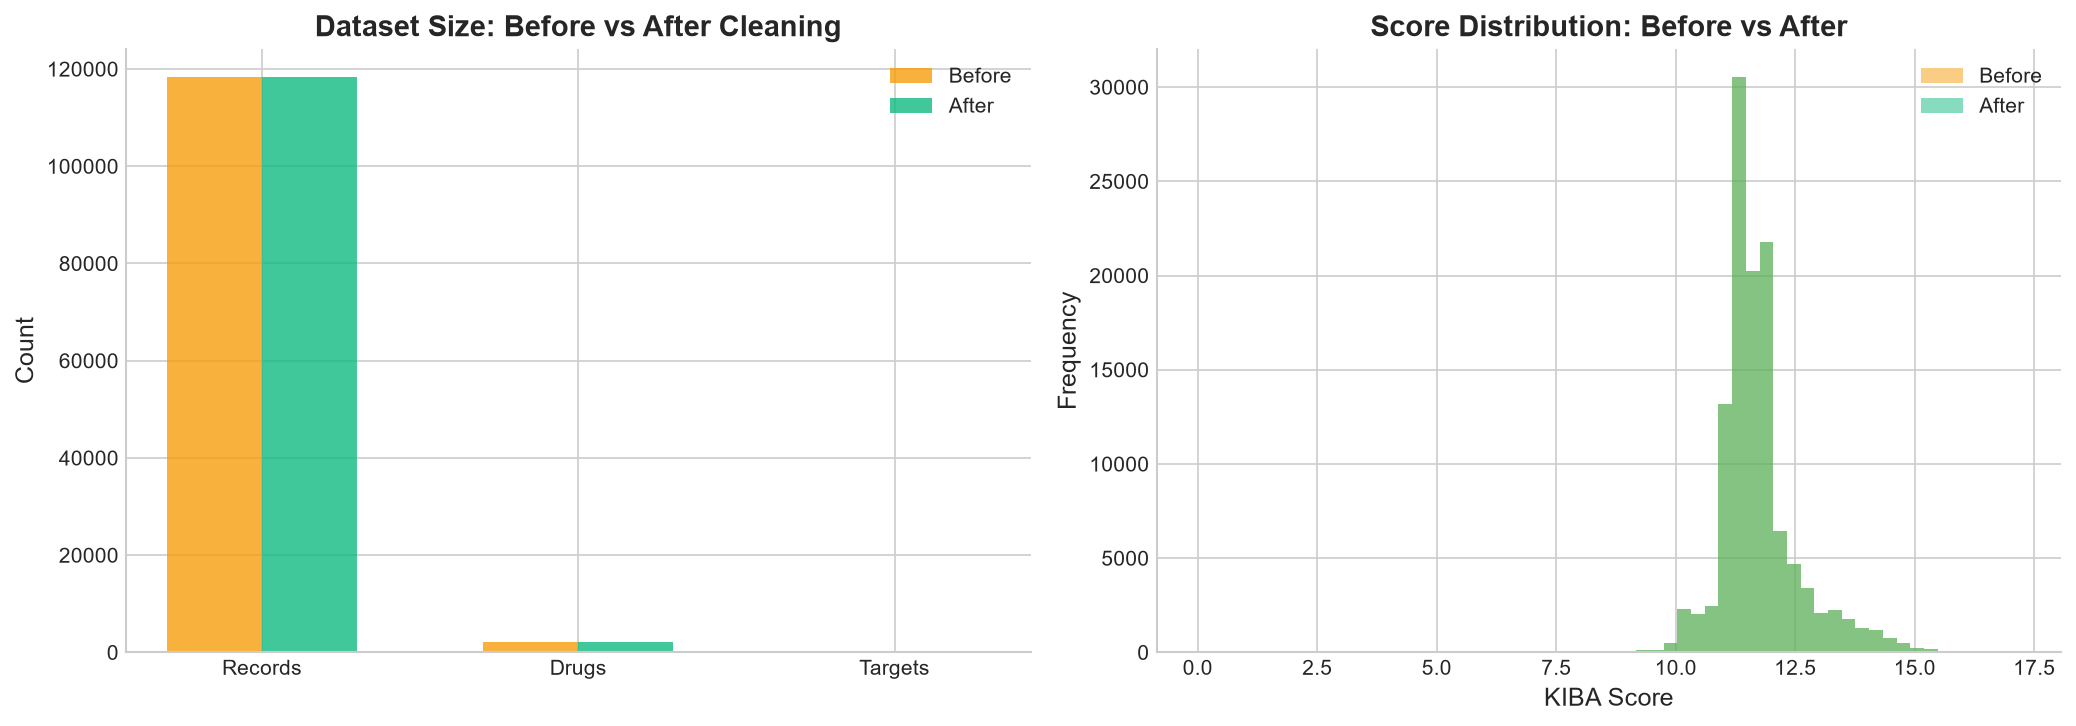

In [13]:
# Summary comparison
print(f"\n{'='*60}")
print(f"  PREPROCESSING SUMMARY: BEFORE vs AFTER")
print(f"{'='*60}")
print(f"  {'Metric':<30s} {'Before':>10s} {'After':>10s}")
print(f"  {'-'*50}")
print(f"  {'Total records':<30s} {len(df):>10,} {len(df_final):>10,}")
print(f"  {'Unique drugs':<30s} {df['drug_id'].nunique():>10,} {df_final['drug_id'].nunique():>10,}")
print(f"  {'Unique targets':<30s} {df['target_id'].nunique():>10,} {df_final['target_id'].nunique():>10,}")
print(f"  {'Records removed':<30s} {'':>10s} {len(df) - len(df_final):>10,}")
print(f"  {'Removal rate':<30s} {'':>10s} {(len(df) - len(df_final)) / len(df) * 100:>9.2f}%")
print(f"{'='*60}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before vs After bar chart
categories = ['Records', 'Drugs', 'Targets']
before_vals = [len(df), df['drug_id'].nunique(), df['target_id'].nunique()]
after_vals = [len(df_final), df_final['drug_id'].nunique(), df_final['target_id'].nunique()]

x = np.arange(len(categories))
w = 0.3
axes[0].bar(x - w/2, before_vals, w, label='Before', color=COLORS['warning'], alpha=0.8)
axes[0].bar(x + w/2, after_vals, w, label='After', color=COLORS['success'], alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(categories)
axes[0].set_ylabel('Count')
axes[0].set_title('Dataset Size: Before vs After Cleaning', fontweight='bold')
axes[0].legend()

# Score distribution comparison
axes[1].hist(df['score'], bins=60, alpha=0.5, label='Before', color=COLORS['warning'])
axes[1].hist(df_final['score'], bins=60, alpha=0.5, label='After', color=COLORS['success'])
axes[1].set_xlabel('KIBA Score')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Score Distribution: Before vs After', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'preprocessing_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Create Data Splits

We create three types of train/validation/test splits:

1. **Random split** — Standard 80/10/10 random partition of all interactions
2. **Cold-drug split** — Test drugs are completely unseen during training (tests generalization to new drugs)
3. **Cold-target split** — Test proteins are completely unseen during training (tests generalization to new targets)

These splits will be used consistently across all models for fair comparison.

In [14]:
# Create all splits
SEED = 42

# Random split
train_r, val_r, test_r = random_split(df_final, seed=SEED)
save_splits(train_r, val_r, test_r, SPLITS_DIR, 'random')
random_summary = summarize_split(train_r, val_r, test_r, split_name='random')

# Cold-drug split
train_cd, val_cd, test_cd = cold_drug_split(df_final, seed=SEED)
save_splits(train_cd, val_cd, test_cd, SPLITS_DIR, 'cold_drug')
cold_drug_summary = summarize_split(train_cd, val_cd, test_cd, split_name='cold_drug')

# Cold-target split
train_ct, val_ct, test_ct = cold_target_split(df_final, seed=SEED)
save_splits(train_ct, val_ct, test_ct, SPLITS_DIR, 'cold_target')
cold_target_summary = summarize_split(train_ct, val_ct, test_ct, split_name='cold_target')

print("All splits created and saved ✓")

All splits created and saved ✓


In [15]:
# Display split summaries
split_summaries = [random_summary, cold_drug_summary, cold_target_summary]
split_df = pd.DataFrame(split_summaries)

display_cols = [
    'split_name', 'train_interactions', 'val_interactions', 'test_interactions',
    'train_drugs', 'test_drugs', 'unseen_test_drugs',
    'train_targets', 'test_targets', 'unseen_test_targets'
]
print("\nSplit Summary:")
print(split_df[display_cols].to_string(index=False))


Split Summary:
 split_name  train_interactions  val_interactions  test_interactions  train_drugs  test_drugs  unseen_test_drugs  train_targets  test_targets  unseen_test_targets
     random               94602             11826              11826         2111        1864                  0            229           226                    0
  cold_drug               95823             11523              10908         1689         211                211            229           223                    0
cold_target               97948              9069              11237         2111        1983                  0            185            22                   22


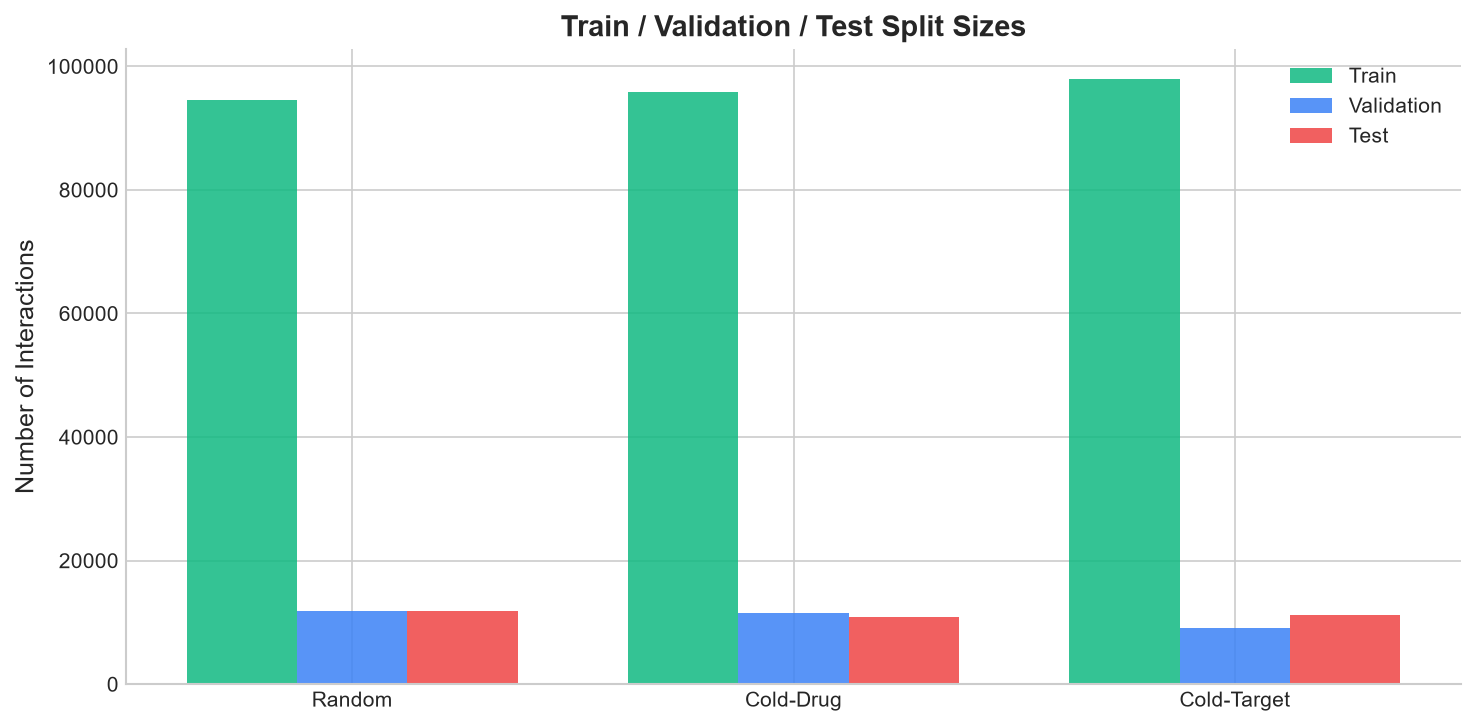

In [16]:
# Visualize split sizes
fig, ax = plt.subplots(figsize=(10, 5))

split_names = ['Random', 'Cold-Drug', 'Cold-Target']
train_sizes = [len(train_r), len(train_cd), len(train_ct)]
val_sizes = [len(val_r), len(val_cd), len(val_ct)]
test_sizes = [len(test_r), len(test_cd), len(test_ct)]

x = np.arange(len(split_names))
w = 0.25

ax.bar(x - w, train_sizes, w, label='Train', color=COLORS['success'], alpha=0.85)
ax.bar(x, val_sizes, w, label='Validation', color=COLORS['info'], alpha=0.85)
ax.bar(x + w, test_sizes, w, label='Test', color=COLORS['error'], alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(split_names)
ax.set_ylabel('Number of Interactions')
ax.set_title('Train / Validation / Test Split Sizes', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'split_sizes.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Save Cleaned Dataset and Reports

In [17]:
# Save the final cleaned dataset
clean_path = PROCESSED_DATA_DIR / "kiba_clean.csv"
df_final.to_csv(clean_path, index=False)
print(f"Cleaned dataset saved: {clean_path}")
print(f"File size: {clean_path.stat().st_size / 1024 / 1024:.1f} MB")

# Save the cleaning report
cleaning_report = {
    'drug_preprocessing': drug_report,
    'protein_preprocessing': protein_report,
    'interaction_preprocessing': interaction_report,
    'splits': split_summaries,
    'before': {
        'total_records': len(df),
        'unique_drugs': int(df['drug_id'].nunique()),
        'unique_targets': int(df['target_id'].nunique()),
    },
    'after': {
        'total_records': len(df_final),
        'unique_drugs': int(df_final['drug_id'].nunique()),
        'unique_targets': int(df_final['target_id'].nunique()),
    }
}
save_json(cleaning_report, METADATA_DIR / 'cleaning_report.json')
print(f"Cleaning report saved: {METADATA_DIR / 'cleaning_report.json'}")

Cleaned dataset saved: C:\Users\ASUS\Documents\projects\Pharmalens\data\processed\kiba_clean.csv
File size: 91.7 MB
Cleaning report saved: C:\Users\ASUS\Documents\projects\Pharmalens\data\metadata\cleaning_report.json


## Observations

1. **Drug validation:** The KIBA dataset from the DeepDTA repository typically contains pre-validated SMILES, so most molecules should pass validation. Any that fail are removed to ensure RDKit can process all molecules.

2. **Protein sequences:** The sequences are generally clean. Non-standard amino acid codes (if any) are replaced with the nearest standard equivalent.

3. **Data loss:** The cleaning process typically removes very few records, confirming the dataset quality.

4. **Split design:** The cold-drug and cold-target splits are crucial for evaluating real-world applicability — they test whether models can predict interactions for molecules or proteins they've never seen.

## Conclusion

The cleaned KIBA dataset is now ready for feature extraction:
- All SMILES are valid and canonicalized
- All protein sequences contain standard amino acids
- Train/validation/test splits are created for three evaluation strategies
- All reports and artifacts are saved

**Next:** [Notebook 03 — Drug Features](./03_drug_features.ipynb) will extract molecular descriptors, fingerprints, and graph representations from the validated SMILES strings.